# Projetando Coordenadas de Centros de Ensaio Clínico para Mapeamento com PROC GPROJECT

## Resumo Executivo

Uma equipe de operações clínicas precisa plotar a pegada geográfica de um ensaio de Fase III multicêntrico em um mapa plano. Este notebook gera coordenadas sintéticas de latitude/longitude para centros do ensaio agrupados em torno de cinco polos regionais dos U.S., e então usa o **PROC GPROJECT** para converter as coordenadas esféricas em valores cartesianos X/Y usando três métodos de projeção (área equivalente de Albers, conforme de Lambert com paralelos padrão personalizados e recorte regional, e Gnomônica centrada nos U.S. continentais), ilustrando como a escolha da projeção e o recorte afetam um mapa de centros.

## Fontes de Dados

| Dataset | Linhas | Variáveis-Chave | Descrição |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 polos x 12 centros) | `site_id` (ID $8), `region` ($12), `x` (longitude, graus, leste-positivo), `y` (latitude, graus), `enroll` (participantes recrutados), `segment` (id do segmento do mapa) | Localizações sintéticas de centros de ensaio de Fase III espalhadas em torno de cinco polos regionais dos U.S. (Oeste, Meio-Oeste, Nordeste, Sul, Sudeste) usando jitter de `rand('normal')` e contagens de recrutamento de `rand('poisson')` |

# Projetando Coordenadas de Centros de Ensaio Clínico com PROC GPROJECT

Quando um patrocinador conduz um ensaio de Fase III geograficamente disperso, o grupo de operações clínicas geralmente quer um único mapa mostrando cada centro investigador, dimensionado ou colorido pelo recrutamento. As localizações dos centros chegam como **pares de longitude/latitude**, mas um mapa plano precisa de **coordenadas planares X/Y**. O `PROC GPROJECT` realiza essa conversão de esférico para cartesiano, aplicando uma projeção cartográfica para que distâncias e áreas sejam renderizadas de forma sensata.

Neste notebook nós:

1. Geramos coordenadas sintéticas de centros agrupadas em torno de cinco polos regionais dos U.S.
2. Aplicamos a projeção padrão de **área equivalente de Albers**.
3. Aplicamos uma projeção **conforme de Lambert** com paralelos padrão personalizados e recorte para os U.S. contíguos.
4. Aplicamos uma projeção **Gnomônica** centrada no meio geográfico do país, mantendo as coordenadas originais com `ASIS`.

Tudo é autocontido: sem arquivos externos, sem rede.

## Etapa 1 — Gerar coordenadas sintéticas dos centros do ensaio

Semeamos o gerador de números aleatórios com `call streaminit` para reprodutibilidade, e então posicionamos 12 centros em torno de cada uma das cinco cidades-polo regionais. As longitudes são armazenadas em graus, leste-positivo (negativas para o Hemisfério Ocidental), e as latitudes em graus. Cada linha também carrega uma contagem de recrutamento e uma variável `segment` (o GPROJECT preserva colunas que não são coordenadas ao longo da projeção).

In [1]:
DADOS trial_sites;
    CHAMAR streaminit(20260531);
    COMPRIMENTO site_id $8 region $12;
    /* Cinco centros regionais dos U.S.: longitude (leste+), latitude */
    VETOR clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    VETOR clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    FAZER hub = 1 ATÉ 5;
        SE hub = 1 ENTÃO region = 'Oeste';
        SENÃO SE hub = 2 ENTÃO region = 'Meio-Oeste';
        SENÃO SE hub = 3 ENTÃO region = 'Nordeste';
        SENÃO SE hub = 4 ENTÃO region = 'Sul';
        SENÃO region = 'Sudeste';
        FAZER s = 1 ATÉ 12;
            site_id = cats('S', PUT(hub, z1.), PUT(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* longitude, graus */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* latitude, graus */
            enroll  = round(rand('poisson', 60));           /* participantes recrutados */
            segment = 1;
            SAÍDA;
        FIM;
    FIM;
    REMOVER hub s;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=trial_sites(obs=10) RÓTULO;
    RÓTULO site_id="ID do Centro" region="Região" x="Longitude" y="Latitude"
          enroll="Recrutados" segment="Segmento";
    TÍTULO "Amostra de Centros Sintéticos de Ensaio Clínico (lon/lat não projetados)";
EXECUTAR;

                        Amostra de Centros Sintéticos de Ensaio Clínico (lon/lat não projetados)                        

  Obs  ID do Centro   Região        Longitude       Latitude  Recrutados  Segmento
    1  S101          Oeste    -121.6437232216  37.7677668495          65         1
    2  S102          Oeste    -120.7384024716  37.5083287903          61         1
    3  S103          Oeste    -121.5133780284  37.8633933883          72         1
    4  S104          Oeste    -121.2086817368  38.7723343392          68         1
    5  S105          Oeste    -121.0499572297   37.175813806          54         1
    6  S106          Oeste    -124.0531899967   35.778231667          72         1
    7  S107          Oeste    -120.9370181032  39.0576714397          64         1
    8  S108          Oeste    -126.8495029747  36.6474680375          55         1
    9  S109          Oeste     -123.475989897  37.1427965254          56         1
   10  S110          Oeste     -122.579780071   


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Etapa 2 — Projeção padrão de área equivalente de Albers

A projeção cônica de área equivalente **Albers** é o padrão do GPROJECT e uma escolha sensata para um mapa em escala de país, onde preservar a *área relativa* importa (por exemplo, comparar o tamanho de áreas de captação regionais).

Como nossas coordenadas são armazenadas em **graus** com **longitude leste-positiva**, especificamos as opções `DEGREE` e `EASTLONG`. A instrução `ID` nomeia a variável que identifica unicamente cada unidade; as coordenadas planares projetadas são gravadas de volta em `x` e `y` no dataset `OUT=`.

In [2]:
PROCEDIMENTO GPROJECT DADOS=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=sites_albers(obs=10) RÓTULO;
    RÓTULO site_id="ID do Centro" region="Região" x="X (Projetado)" y="Y (Projetado)"
          enroll="Recrutados" segment="Segmento";
    TÍTULO "Centros do Ensaio Após Projeção Albers de Área Equivalente (X/Y planar)";
EXECUTAR;

                        Amostra de Centros Sintéticos de Ensaio Clínico (lon/lat não projetados)                        

                        Centros do Ensaio Após Projeção Albers de Área Equivalente (X/Y planar)                         

  Obs  ID do Centro   Região  X (Projetado)  Y (Projetado)  Recrutados  Segmento
    1  S101          Oeste     -0.346124731   0.0516986079          65         1
    2  S102          Oeste    -0.3353644139   0.0440400181          61         1
    3  S103          Oeste    -0.3439609675   0.0528501365          72         1
    4  S104          Oeste    -0.3357513354    0.067213083          68         1
    5  S105          Oeste    -0.3410170723   0.0394882801          54         1
    6  S106          Oeste    -0.3879364507   0.0273340733          72         1
    7  S107          Oeste    -0.3309127579   0.0711146305          64         1
    8  S108          Oeste    -0.4204191205   0.0538118922          55         1
    9  S109          Oeste 


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Etapa 3 — Projeção conforme de Lambert com paralelos e recorte personalizados

A projeção cônica **conforme de Lambert** preserva *forma e ângulos locais*, o que é preferível quando o mapa é usado para navegação ou para sobrepor feições direcionais. Para os U.S. contíguos, paralelos padrão próximos a 33 graus N e 45 graus N são convencionais, então os definimos explicitamente com `PARALLEL1=` e `PARALLEL2=`.

Também restringimos o mapa à janela dos U.S. contíguos usando as opções de recorte `LATMIN=`, `LATMAX=`, `LONGMIN=` e `LONGMAX=`. Quaisquer centros que caiam fora dessa caixa de latitude/longitude são descartados antes da projeção, então a contagem de observações de saída pode ser menor que a de entrada.

In [3]:
PROCEDIMENTO GPROJECT DADOS=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=sites_lambert(obs=10) RÓTULO;
    RÓTULO site_id="ID do Centro" region="Região" x="X (Projetado)" y="Y (Projetado)"
          enroll="Recrutados" segment="Segmento";
    TÍTULO "Centros do Ensaio Após Projeção Conforme de Lambert (recortada para os U.S. contíguos)";
EXECUTAR;

                        Centros do Ensaio Após Projeção Albers de Área Equivalente (X/Y planar)                         

                 Centros do Ensaio Após Projeção Conforme de Lambert (recortada para os U.S. contíguos)                 

  Obs  ID do Centro   Região  X (Projetado)  Y (Projetado)  Recrutados  Segmento
    1  S101          Oeste    -0.3473024124   0.0279382533          65         1
    2  S102          Oeste    -0.3365626234   0.0201991247          61         1
    3  S103          Oeste    -0.3451238364   0.0290365995          72         1
    4  S104          Oeste    -0.3367881094   0.0430616123          68         1
    5  S105          Oeste    -0.3422656751   0.0158037156          54         1
    6  S106          Oeste    -0.3894389642   0.0046370991          72         1
    7  S107          Oeste    -0.3319086764   0.0468276119          64         1
    8  S109          Oeste    -0.3746144745   0.0248234546          56         1
    9  S110          Oeste 


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Etapa 4 — Projeção Gnomônica centrada no país, mantendo os originais

A projeção azimutal **Gnomônica** renderiza cada círculo máximo como uma linha reta, o que é útil quando você quer raciocinar sobre o caminho mais curto entre centros (por exemplo, planejar a rota de viagem de visita de um monitor). A distorção cresce com a distância do polo de projeção, então centramos o polo no meio geográfico dos U.S. continentais com `POLELAT=39` e `POLELONG=-98`.

A opção `ASIS` diz ao GPROJECT para manter as coordenadas originais não projetadas junto com os valores projetados, então o dataset de saída carrega tanto o `X`/`Y` planar quanto o `LONG`/`LAT` de origem — útil para unir métricas de recrutamento de volta a qualquer um dos espaços de coordenadas.

A instrução `PARMENTRY` é mostrada como uma forma alternativa de fornecer parâmetros de projeção como sobrescritas chave=valor.

In [4]:
PROCEDIMENTO GPROJECT DADOS=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=sites_gnomon(obs=10) RÓTULO;
    RÓTULO site_id="ID do Centro" region="Região" x="X (Projetado)" y="Y (Projetado)"
          enroll="Recrutados" segment="Segmento" long="Longitude (Original)"
          lat="Latitude (Original)";
    TÍTULO "Centros do Ensaio Após Projeção Gnomônica (ASIS mantém o LONG/LAT original)";
EXECUTAR;

                 Centros do Ensaio Após Projeção Conforme de Lambert (recortada para os U.S. contíguos)                 

                      Centros do Ensaio Após Projeção Gnomônica (ASIS mantém o LONG/LAT original)                       

  Obs  ID do Centro   Região  X (Projetado)  Y (Projetado)  Recrutados  Segmento  Longitude (Original)  Latitude (Original)
    1  S101          Oeste    -0.3343477981   0.0213614461          65         1       -121.6437232216        37.7677668495
    2  S102          Oeste    -0.3221611694   0.0134152735          61         1       -120.7384024716        37.5083287903
    3  S103          Oeste    -0.3319480803   0.0225717184          72         1       -121.5133780284        37.8633933883
    4  S104          Oeste    -0.3230855797   0.0375741352          68         1       -121.2086817368        38.7723343392
    5  S105          Oeste    -0.3283677206   0.0086308769          54         1       -121.0499572297         37.175813806
    6  S106 


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Etapa 5 — Renderizar o mapa de centros projetado

Todo o propósito de projetar é desenhar o mapa. Alimentamos o dataset `OUT=` de Albers diretamente no **PROC SGPLOT**, plotando o `X`/`Y` planar e colorindo cada marcador por `region`. Como a projeção preservou a geografia relativa, os cinco agrupamentos de polos caem nos cantos esperados do gráfico — Oeste à esquerda, Nordeste no canto superior direito, Sul e Sudeste ao longo da parte inferior — dando às operações clínicas a pegada fiel à área descrita no resumo executivo.

                      Centros do Ensaio Após Projeção Gnomônica (ASIS mantém o LONG/LAT original)                       




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


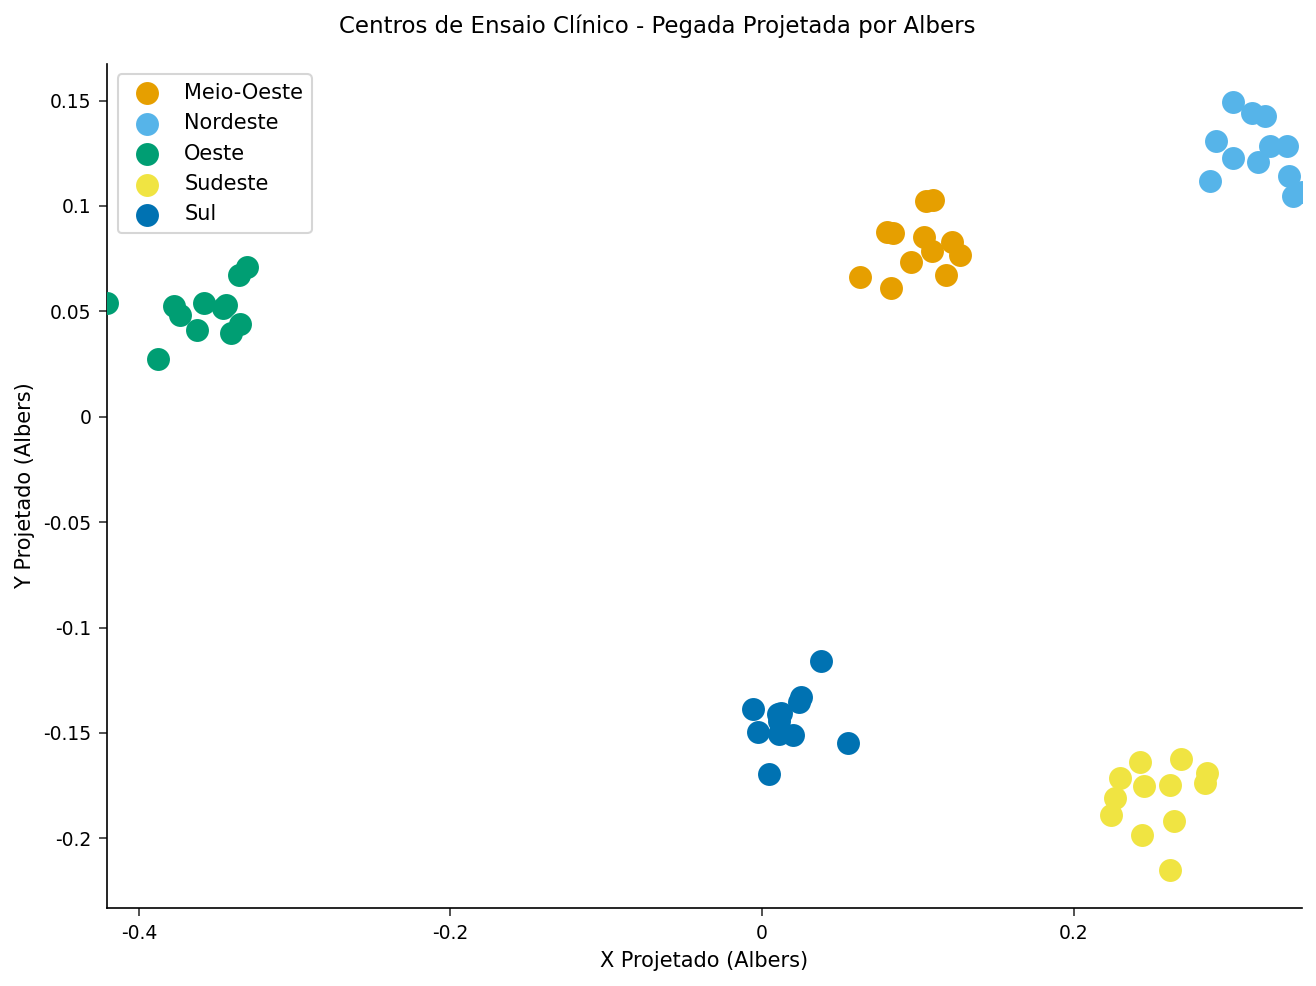

In [5]:
PROCEDIMENTO SGPLOT DADOS=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS RÓTULO="X Projetado (Albers)";
    YAXIS RÓTULO="Y Projetado (Albers)";
    TÍTULO "Centros de Ensaio Clínico - Pegada Projetada por Albers";
EXECUTAR;

## Interpretando os resultados

- **Albers (Etapa 2)** transformou todos os 60 centros em coordenadas planares preservando a área relativa — os agrupamentos Oeste, Meio-Oeste, Nordeste, Sul e Sudeste mantêm sua pegada espacial proporcional, que é a base correta para um mapa de calor de recrutamento fiel à área.
- **Lambert com recorte (Etapa 3)** preservou a forma local e, ao aplicar a janela `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`, descartou os centros sintéticos que se espalharam para fora dos U.S. contíguos — aqui a contagem caiu de 60 para 58, então as duas coordenadas fora da grade que de outra forma esticariam o mapa foram removidas antes da projeção.
- **Gnomônica com `ASIS` (Etapa 4)** centrou a projeção no interior do país e, graças ao `ASIS`, produziu um dataset carregando tanto o `X`/`Y` projetado quanto o `LONG`/`LAT` original. Círculos máximos aparecem como linhas retas, então distâncias em linha reta neste mapa aproximam os verdadeiros caminhos mais curtos entre os centros.
- **A pegada renderizada (Etapa 5)** confirma que a projeção funcionou: plotar o `X`/`Y` de Albers por região posiciona os cinco agrupamentos de polos em seus cantos esperados no plano, o mapa de centros fiel à área que o resumo executivo prometeu.

**Conclusão para operações clínicas:** a projeção não é cosmética. Escolha **Albers** para densidade de recrutamento fiel à área, **Lambert** para sobreposições fiéis à forma com recorte regional, e **Gnomônica** quando a distância de viagem entre centros direciona a análise. Como a Etapa 5 mostra, o dataset `OUT=` projetado se encaixa diretamente no PROC SGPLOT (ou PROC GMAP) para renderizar o mapa final de centros.